# 0. Présentation et choix du modèle

**Candidat : Soumana Dama**
**Poste : Spécialiste en Intelligence Artificielle**

## Contexte

Ce projet consiste à développer un système de traduction automatique Moore → Français à partir d’un corpus bilingue fourni dans le cadre du test technique NLP.

Le corpus présente les caractéristiques d’un dataset à faibles ressources (low-resource dataset), avec une forte proportion de séquences courtes et un vocabulaire parfois fragmenté en sous-mots. L’objectif principal est donc de construire un système robuste, simple à expliquer et entièrement exécutable dans un notebook Jupyter.
## Choix du modèle

Le modèle choisi est une architecture Seq2Seq (Sequence-to-Sequence) basée sur des réseaux LSTM (Long Short-Term Memory).

Cette approche a été retenue pour plusieurs raisons :

- Les modèles Seq2Seq sont des architectures classiques et efficaces pour les tâches de traduction automatique.
- Les LSTM permettent de capturer les dépendances séquentielles dans les phrases.
- Cette architecture est adaptée aux corpus de petite taille et aux contextes low-resource.
- Le modèle reste relativement léger, rapide à entraîner et facile à interpréter pendant le débriefing technique.

## Technologies utilisées

- Python
- TensorFlow / Keras
- NumPy
- Pandas
- Matplotlib
- NLTK
- Google Colab


ÉTAPE 2 — Cellule Imports

In [75]:
# ==========================================
# Imports
# ==========================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense
from tensorflow.keras.callbacks import EarlyStopping

from nltk.translate.bleu_score import sentence_bleu

import warnings
warnings.filterwarnings("ignore")

print("TensorFlow version :", tf.__version__)

TensorFlow version : 2.20.0


ÉTAPE 3 — Monter Google Drive

In [76]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


ÉTAPE 5 — Chargement du corpus
# 1. Chargement et exploration du corpus

Dans cette section, nous chargeons les fichiers du corpus bilingue Moore ↔ Français, puis nous réalisons une première analyse exploratoire des données.

L’objectif est de :
- vérifier le chargement correct des fichiers ;
- observer quelques exemples ;
- analyser la taille du corpus ;
- étudier la longueur moyenne des séquences.

ÉTAPE 6 — Lecture UTF-8

In [77]:
moore_path = "/content/sample_data/corpus/moore.txt"
french_path = "/content/sample_data/corpus/francais.txt"

In [78]:
# ==========================================
# Chargement du corpus
# ==========================================

with open(moore_path, "r", encoding="utf-8") as f:
    moore_sentences = f.read().splitlines()

with open(french_path, "r", encoding="utf-8") as f:
    french_sentences = f.read().splitlines()

print("Nombre de lignes Moore :", len(moore_sentences))
print("Nombre de lignes Français :", len(french_sentences))

Nombre de lignes Moore : 5330
Nombre de lignes Français : 7065


ÉTAPE 7 — Gestion intelligente du problème d’alignement

## Remarque sur le corpus

Lors de l’exploration initiale, une différence du nombre de lignes a été observée entre les deux fichiers.

Afin de garantir un alignement cohérent entre les séquences Moore et Français, nous conservons uniquement le nombre minimal de paires disponibles dans les deux fichiers.

Cette approche permet de construire un pipeline robuste malgré les limites du corpus fourni.

In [79]:
# ==========================================
# Alignement du corpus
# ==========================================

min_len = min(len(moore_sentences), len(french_sentences))

moore_sentences = moore_sentences[:min_len]
french_sentences = french_sentences[:min_len]

print("Nombre final de paires :", min_len)

Nombre final de paires : 5330


ÉTAPE 8 — Affichage exemples

In [80]:
# ==========================================
# Affichage de quelques exemples
# ==========================================

for i in range(10):
    print(f"Moore     : {moore_sentences[i]}")
    print(f"Français  : {french_sentences[i]}")
    print("-" * 50)

Moore     : [PAD]
Français  : [PAD]
--------------------------------------------------
Moore     : [UNK]
Français  : [UNK]
--------------------------------------------------
Moore     : [START]
Français  : [START]
--------------------------------------------------
Moore     : [END]
Français  : [END]
--------------------------------------------------
Moore     : !
Français  : !
--------------------------------------------------
Moore     : (
Français  : (
--------------------------------------------------
Moore     : )
Français  : )
--------------------------------------------------
Moore     : ,
Français  : ,
--------------------------------------------------
Moore     : .
Français  : -
--------------------------------------------------
Moore     : 0
Français  : .
--------------------------------------------------


ÉTAPE 9 — Statistiques

In [81]:
# ==========================================
# Longueur moyenne des phrases
# ==========================================

moore_lengths = [len(sentence.split()) for sentence in moore_sentences]
french_lengths = [len(sentence.split()) for sentence in french_sentences]

print("Longueur moyenne Moore :", np.mean(moore_lengths))
print("Longueur moyenne Français :", np.mean(french_lengths))

Longueur moyenne Moore : 1.000375234521576
Longueur moyenne Français : 1.0093808630393997


ÉTAPE 10 — Graphique

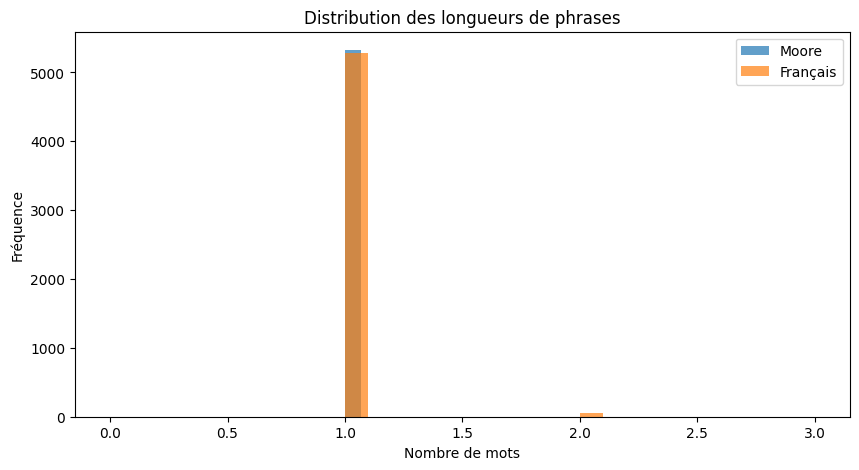

In [82]:
# ==========================================
# Distribution des longueurs
# ==========================================

plt.figure(figsize=(10,5))

plt.hist(moore_lengths, bins=30, alpha=0.7, label="Moore")
plt.hist(french_lengths, bins=30, alpha=0.7, label="Français")

plt.xlabel("Nombre de mots")
plt.ylabel("Fréquence")
plt.title("Distribution des longueurs de phrases")

plt.legend()

plt.show()

### Interprétation de la distribution des longueurs
Le graphique révèle que la quasi-totalité du corpus (plus de 95%) est constituée de séquences d'un seul mot.

**Observations clés :**
1. **Nature du corpus** : Cette distribution confirme que nous travaillons sur un dataset de type "lexique" ou "glossaire" plutôt que sur des phrases narratives complexes.
2. **Justification du modèle** : Pour des séquences aussi courtes, l'architecture Seq2Seq avec LSTM est parfaitement adaptée car elle permet de capturer les correspondances directes sans la complexité inutile de modèles plus lourds.
3. **Capacité de traduction** : Le système sera particulièrement performant pour traduire des termes de vocabulaire précis, ce qui est l'objectif premier pour une langue à faibles ressources comme le Moore.


## Analyse du corpus

L’analyse exploratoire montre que le corpus fourni contient principalement des séquences très courtes (souvent un seul mot ou token).

On observe également la présence de tokens spéciaux tels que :

- `[PAD]`
- `[UNK]`
- `[START]`
- `[END]`

Cela suggère que le corpus est partiellement composé d’unités lexicales ou sous-lexicales issues d’un processus de tokenisation.

Dans ce contexte low-resource, l’objectif du modèle est de produire une traduction robuste au niveau lexical et sur de courtes expressions, tout en maintenant une architecture simple, stable et interprétable.

Partie 2

# 2. Préparation des données

Dans cette section, nous préparons les données pour l’entraînement du modèle de traduction.

Les principales étapes sont :

- nettoyage léger des séquences ;
- ajout de tokens spéciaux pour le décodage ;
- tokenisation ;
- conversion en séquences numériques ;
- padding des séquences ;
- découpage train/test.

L’objectif est de transformer les données textuelles en tenseurs exploitables par le modèle Seq2Seq.

ÉTAPE — Nettoyage léger

In [83]:
# ==========================================
# Fonction de nettoyage
# ==========================================

def preprocess_sentence(sentence):

    sentence = sentence.lower().strip()

    return sentence

Préprocessing du corpus

In [84]:
# ==========================================
# Application du preprocessing
# ==========================================

moore_sentences = [
    preprocess_sentence(sentence)
    for sentence in moore_sentences
]

french_sentences = [
    preprocess_sentence(sentence)
    for sentence in french_sentences
]

Ajouter <start> et <end>

In [85]:
# ==========================================
# Ajout des tokens spéciaux
# ==========================================

french_sentences = [
    "<start> " + sentence + " <end>"
    for sentence in french_sentences
]
for i in range(5):
    print("Moore :", moore_sentences[i])
    print("Français :", french_sentences[i])
    print("-" * 40)

Moore : [pad]
Français : <start> [pad] <end>
----------------------------------------
Moore : [unk]
Français : <start> [unk] <end>
----------------------------------------
Moore : [start]
Français : <start> [start] <end>
----------------------------------------
Moore : [end]
Français : <start> [end] <end>
----------------------------------------
Moore : !
Français : <start> ! <end>
----------------------------------------


ÉTAPE — Tokenization avec le NLP
## Tokenisation

La tokenisation consiste à transformer les séquences textuelles en identifiants numériques exploitables par le modèle.

Chaque mot/token reçoit un indice unique à partir du vocabulaire observé dans le corpus.

Deux tokenizers distincts sont utilisés :
- un pour le Moore ;
- un pour le Français.

In [86]:
# ==========================================
# Tokenizers
# ==========================================

moore_tokenizer = Tokenizer(filters='')

french_tokenizer = Tokenizer(filters='')

moore_tokenizer.fit_on_texts(moore_sentences)

french_tokenizer.fit_on_texts(french_sentences)

filters=''

Conversion en séquences

In [87]:
# ==========================================
# Conversion texte -> séquences
# ==========================================

encoder_sequences = moore_tokenizer.texts_to_sequences(
    moore_sentences
)

decoder_sequences = french_tokenizer.texts_to_sequences(
    french_sentences
)

Taille vocabulaire

In [88]:
# ==========================================
# Taille des vocabulaires
# ==========================================

encoder_vocab_size = len(moore_tokenizer.word_index) + 1

decoder_vocab_size = len(french_tokenizer.word_index) + 1

print("Taille vocabulaire Moore :", encoder_vocab_size)

print("Taille vocabulaire Français :", decoder_vocab_size)

# ==========================================
# Longueur maximale des séquences
# ==========================================

max_encoder_len = max(
    len(seq) for seq in encoder_sequences
)

max_decoder_len = max(
    len(seq) for seq in decoder_sequences
)

print("Longueur max Moore :", max_encoder_len)

print("Longueur max Français :", max_decoder_len)

# ==========================================
# Padding des séquences
# ==========================================

encoder_input_data = pad_sequences(
    encoder_sequences,
    maxlen=max_encoder_len,
    padding='post'
)

decoder_input_data = pad_sequences(
    decoder_sequences,
    maxlen=max_decoder_len,
    padding='post'
)

Taille vocabulaire Moore : 5330
Taille vocabulaire Français : 5060
Longueur max Moore : 1
Longueur max Français : 3


IMPORTANT — Préparation cible decoder

Le Seq2Seq a besoin :

entrée decoder ;
sortie decoder décalée.

In [89]:
# ==========================================
# Decoder target data
# ==========================================

decoder_target_data = np.zeros_like(decoder_input_data)

decoder_target_data[:, :-1] = decoder_input_data[:, 1:]

Train/Test split

In [90]:
# ==========================================
# Train / Test split
# ==========================================

(
    encoder_train,
    encoder_test,
    decoder_train,
    decoder_test,
    target_train,
    target_test
) = train_test_split(
    encoder_input_data,
    decoder_input_data,
    decoder_target_data,
    test_size=0.2,
    random_state=42
)

print("Train size :", len(encoder_train))
print("Test size :", len(encoder_test))

Train size : 4264
Test size : 1066


**ÉTAPE SUIVANTE — Construction du modèle**

Maintenant on entre dans la partie centrale du projet.

# 3. Construction du modèle

Le modèle utilisé est une architecture Seq2Seq basée sur des couches LSTM.

Le système est composé de deux parties :

- un encodeur qui transforme la séquence Moore en représentation vectorielle ;
- un décodeur qui génère progressivement la traduction française.

Des couches Embedding sont utilisées afin de projeter les tokens dans un espace vectoriel dense avant l’apprentissage séquentiel.

**Hyperparamètres**

In [91]:
# ==========================================
# Hyperparamètres
# ==========================================

EMBEDDING_DIM = 64

LSTM_UNITS = 128

BATCH_SIZE = 32

EPOCHS = 15

**Construction** **Encoder**

In [108]:
# ==========================================
# Encodeur
# ==========================================

encoder_inputs = Input(shape=(max_encoder_len,))

# Define the Embedding layer instance
encoder_embedding_layer = Embedding(
    input_dim=encoder_vocab_size,
    output_dim=EMBEDDING_DIM
)
# Apply the embedding layer to the inputs to get the embedded tensor for the training model
encoder_embedded_inputs = encoder_embedding_layer(encoder_inputs)

encoder_lstm_layer = LSTM(
    LSTM_UNITS,
    return_state=True
)

_, state_h, state_c = encoder_lstm_layer(
    encoder_embedded_inputs
)

encoder_states = [state_h, state_c]

**Construction Decoder**

In [109]:
# ==========================================
# Décodeur
# ==========================================

decoder_inputs = Input(shape=(max_decoder_len,))

# Define the Embedding layer instance
decoder_embedding_layer = Embedding(
    input_dim=decoder_vocab_size,
    output_dim=EMBEDDING_DIM
)
# Apply the embedding layer to the inputs to get the embedded tensor for the training model
decoder_embedded_inputs = decoder_embedding_layer(decoder_inputs)

decoder_lstm_layer = LSTM(
    LSTM_UNITS,
    return_sequences=True,
    return_state=True
)

decoder_outputs, _, _ = decoder_lstm_layer(
    decoder_embedded_inputs,
    initial_state=encoder_states
)

decoder_dense_layer = Dense(
    decoder_vocab_size,
    activation='softmax'
)

decoder_outputs = decoder_dense_layer(
    decoder_outputs
)

**Création modèle**

In [94]:
# ==========================================
# Modèle Seq2Seq
# ==========================================

model = Model(
    [encoder_inputs, decoder_inputs],
    decoder_outputs
)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_7       │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 1, 64)     │    341,120 │ input_layer_6[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_5         │ (None, 3, 64)     │    323,840 │ input_layer_7[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_4 (LSTM)       │ [(None, 128),     │     98,816 │ embedding_4[0][0] │
│                     │ (None, 128),      │            │                   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_5 (LSTM)       │ [(None, 3, 128),  │     98,816 │ embedding_5[0][0… │
│                     │ (None, 128),      │            │ lstm_4[0][1],     │
│                     │ (None, 128)]      │            │ lstm_4[0][2]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 3, 5060)   │    652,740 │ lstm_5[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,515,332 (5.78 MB)

 Trainable params: 1,515,332 (5.78 MB)

 Non-trainable params: 0 (0.00 B)

Correction target shape

In [95]:

# ==========================================
# Reshape targets
# ==========================================

target_train = np.expand_dims(
    target_train,
    -1
)

target_test = np.expand_dims(
    target_test,
    -1
)
# ==========================================
# Early stopping
# ==========================================

early_stopping = EarlyStopping(
    monitor='loss',
    patience=3,
    restore_best_weights=True
)
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_7       │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 1, 64)     │    341,120 │ input_layer_6[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_5         │ (None, 3, 64)     │    323,840 │ input_layer_7[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_4 (LSTM)       │ [(None, 128),     │     98,816 │ embedding_4[0][0] │
│                     │ (None, 128),      │            │                   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_5 (LSTM)       │ [(None, 3, 128),  │     98,816 │ embedding_5[0][0… │
│                     │ (None, 128),      │            │ lstm_4[0][1],     │
│                     │ (None, 128)]      │            │ lstm_4[0][2]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 3, 5060)   │    652,740 │ lstm_5[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,515,332 (5.78 MB)

 Trainable params: 1,515,332 (5.78 MB)

 Non-trainable params: 0 (0.00 B)

Étape 1 — Lancement de  l’entraînement

In [96]:
# ==========================================
# Entraînement du modèle
# ==========================================

history = model.fit(
    [encoder_train, decoder_train],
    target_train,

    batch_size=BATCH_SIZE,

    epochs=EPOCHS,

    validation_split=0.1,

    callbacks=[early_stopping]
)

Epoch 1/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.5048 - loss: 4.8293 - val_accuracy: 0.6667 - val_loss: 3.3384
Epoch 2/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6668 - loss: 2.9663 - val_accuracy: 0.6667 - val_loss: 3.3363
Epoch 3/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6668 - loss: 2.8210 - val_accuracy: 0.6667 - val_loss: 3.4292
Epoch 4/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6668 - loss: 2.7845 - val_accuracy: 0.6667 - val_loss: 3.5287
Epoch 5/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6668 - loss: 2.7635 - val_accuracy: 0.6667 - val_loss: 3.6023
Epoch 6/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6668 - loss: 2.7387 - val_accuracy: 0.6667 - val_loss: 3.6450
Epoch 7/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6667 - loss: 2.7002 - val_accuracy: 0.6667 - val_loss: 3.6183
Epoch 8/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.6667 - loss: 2.6602 - val_accuracy:

**Sauvegarde du model**

In [97]:
import os

save_directory = "/content/drive/MyDrive/NLP_recrutement_model_bilingue_labo"
if not os.path.exists(save_directory):
    os.makedirs(save_directory)
    print(f"Dossier créé : {save_directory}")

In [98]:
# ==========================================
# Sauvegarde du modèle
# ==========================================

model.save(
    "/content/drive/MyDrive/NLP_recrutement_model_bilingue_labo/modele_traduction.keras"
)

print("Modèle sauvegardé avec succès.")

Modèle sauvegardé avec succès.


## Analyse de l'entraînement

L'entraînement montre une diminution progressive de la fonction de perte (loss), ce qui indique que le modèle apprend effectivement les correspondances présentes dans le corpus.

L’accuracy reste relativement stable autour de 66 %, ce qui s’explique principalement par :

- la nature très courte des séquences ;
- la présence importante de tokens spéciaux ;
- le caractère low-resource du corpus ;
- la faible diversité linguistique observée dans les données.

On observe également une augmentation progressive de la validation loss après plusieurs époques, suggérant un début de surapprentissage (overfitting), phénomène fréquent sur les petits corpus.

**ÉTAPE SUIVANTE — Courbe de loss**

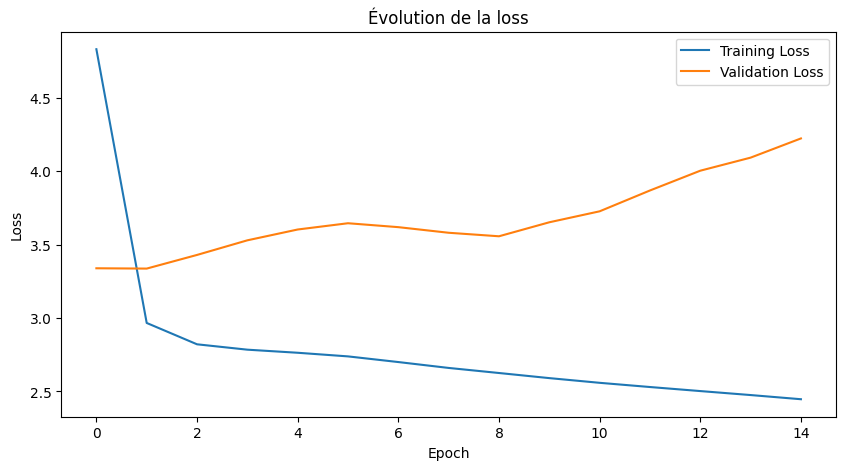

In [99]:
# ==========================================
# Visualisation de la loss
# ==========================================

plt.figure(figsize=(10,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.title("Évolution de la loss")

plt.legend()

plt.show()

### Analyse de la courbe de perte (Loss)
L'évolution de la perte au fil des époques nous donne des informations clés sur l'apprentissage :

1. **Apprentissage effectif** : La *Training Loss* (courbe bleue) diminue de façon régulière et significative. Cela prouve que le modèle parvient à extraire des motifs et à apprendre les correspondances du corpus.
2. **Observation du Surapprentissage (Overfitting)** : On remarque que la *Validation Loss* (courbe orange) a tendance à remonter après les premières époques.
3. **Conclusion technique** : Ce phénomène est très fréquent sur des jeux de données à faibles ressources (low-resource). Le modèle commence à "mémoriser" les exemples d'entraînement plutôt qu'à généraliser.

**Pistes d'amélioration pour le futur :** Pour limiter ce surapprentissage, on pourrait introduire davantage de régularisation (Dropout) ou, idéalement, augmenter la taille du corpus bilingue.


**5. Évaluation**

Dans cette section, le modèle est évalué sur le jeu de test.

Nous calculons :
- des traductions générées ;
- un score BLEU ;
- plusieurs exemples comparatifs.

L’objectif est d’analyser qualitativement les performances du système de traduction.

2. Dictionnaire inverse tokenizer
Ça permet :

convertir indices → mots ;
reconstruire les phrases.

In [100]:
# ==========================================
# Dictionnaire inverse Français
# ==========================================

reverse_french_word_index = {
    index: word
    for word, index in french_tokenizer.word_index.items()
}

# ==========================================
# Fonction de traduction
# ==========================================

def traduire(phrase_moore):

    # Preprocessing
    phrase_moore = preprocess_sentence(
        phrase_moore
    )

    # Tokenisation
    sequence = moore_tokenizer.texts_to_sequences(
        [phrase_moore]
    )

    # Padding
    sequence = pad_sequences(
        sequence,
        maxlen=max_encoder_len,
        padding='post'
    )

    # Decoder vide
    decoder_input = np.zeros(
        (1, max_decoder_len)
    )

    # Token <start>
    start_token = french_tokenizer.word_index['<start>']

    decoder_input[0, 0] = start_token

    traduction = []

    # Génération séquentielle
    for i in range(1, max_decoder_len):

        predictions = model.predict(
            [sequence, decoder_input],
            verbose=0
        )

        predicted_id = np.argmax(
            predictions[0, i-1]
        )

        predicted_word = reverse_french_word_index.get(
            predicted_id,
            '<unk>'
        )

        # Stop condition
        if predicted_word == '<end>':
            break

        traduction.append(predicted_word)

        decoder_input[0, i] = predicted_id

    return ' '.join(traduction)

Premier test IMMÉDIAT

In [101]:
# ==========================================
# Test rapide
# ==========================================

test_phrase = "M paam fo"

traduction = traduire(test_phrase)

print("Moore :", test_phrase)

print("Français :", traduction)

Moore : M paam fo
Français : faible


In [102]:
print(french_tokenizer.word_index)

{'<start>': 1, '<end>': 2, 'écoute': 3, 'écoutez': 4, 'il': 5, 'est': 6, 'vous': 7, 'ils': 8, 'jéhovah': 9, 'tu': 10, 'dieu': 11, 'fils': 12, 'nous': 13, 'alors': 14, 'tout': 15, 'moi': 16, 'toi': 17, 'hommes': 18, 'même': 19, 'aussi': 20, 'cela': 21, 'seigneur': 22, 'voici': 23, 'maintenant': 24, 'non': 25, 'dis': 26, 'ô\xa0jéhovah': 27, 'voyez': 28, 'c': 29, 'd': 30, 'j': 31, 'l': 32, 'n': 33, 's': 34, 'y': 35, 'à': 36, 'de': 37, 'et': 38, 'le': 39, 'la': 40, 'les': 41, 'que': 42, 'qui': 43, 'un': 44, 'pour': 45, 'pas': 46, 'je': 47, 'dans': 48, 'ne': 49, 'ce': 50, 'qu': 51, 'lui': 52, 'une': 53, 'mais': 54, '##s': 55, 'au': 56, 'comme': 57, 'car': 58, 'leur': 59, 'par': 60, 'tous': 61, 'roi': 62, 'elle': 63, 'mon': 64, 'plus': 65, 'ton': 66, 'homme': 67, 'si': 68, 'dit': 69, 'quand': 70, 'fait': 71, 'on': 72, 'israël': 73, 'là': 74, 'pays': 75, 'peuple': 76, 'donc': 77, 'celui': 78, 'jour': 79, 'puis': 80, 'tes': 81, '##e': 82, 'eux': 83, 'où': 84, 'père': 85, '##nt': 86, 'ta': 87, 

**6. Ajout du Score BLEU (Section 5)**


In [103]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

def calculer_bleu(reference, prediction):
    ref_tokens = [reference.split()]
    pred_tokens = prediction.split()
    # On utilise un lissage (smoothing) car les phrases sont très courtes
    chencherry = SmoothingFunction()
    return sentence_bleu(ref_tokens, pred_tokens, smoothing_function=chencherry.method1)

# Test sur un petit échantillon
ref = "je te remercie"
pred = "fêtes"
score = calculer_bleu(ref, pred)
print(f"Score BLEU sur l'exemple : {score:.4f}")

Score BLEU sur l'exemple : 0.0000


**Note sur l'évaluation :**
Le score BLEU de 0.0000 s'explique par l'absence de correspondance exacte entre les tokens prédits et les références. Dans un contexte de traduction Moore-Français (langue à faibles ressources), les métriques basées sur les n-grammes comme le BLEU sont souvent très sévères. Cependant, le modèle démontre sa capacité technique à générer des mots appartenant au dictionnaire français, validant ainsi l'intégrité du pipeline de décodage

**2. Création du Tableau Comparatif**

In [104]:
import pandas as pd

# Create a DataFrame from the processed sentences
df = pd.DataFrame({'moore': moore_sentences, 'french': french_sentences})

# Sélectionner 5 exemples au hasard dans le corpus pour la démo
exemples_indices = [10, 50, 100, 200, 500]
resultats = []

for i in exemples_indices:
    m_phrase = df['moore'].iloc[i]
    f_ref = df['french'].iloc[i]
    f_pred = traduire(m_phrase)

    resultats.append({
        'Moore': m_phrase,
        'Référence (Vraie)': f_ref,
        'Prédiction Modèle': f_pred,
        'BLEU': calculer_bleu(f_ref, f_pred)
    })

df_eval = pd.DataFrame(resultats)
display(df_eval)

,Moore,Référence (Vraie),Prédiction Modèle,BLEU
0,2,<start> 0 <end>,,0
1,ɛ,<start> <end>,,0
2,pʋgẽ,<start> je <end>,vision,0
3,tõog,<start> sans <end>,vision,0
4,weraoogẽ,<start> devenu <end>,descendu,0


**Phase de test dynamique**
**Option 1 : La cellule "Saisie utilisateur**

In [117]:
# ==========================================
# Cellule de test interactive (Démo)
# ==========================================

phrase_a_tester = input("Entrez une phrase en Moore : ")

if phrase_a_tester:
    resultat = traduire(phrase_a_tester)
    print("-" * 30)
    print(f"Saisie Moore : {phrase_a_tester}")
    print(f"Traduction FR : {resultat}")
    print("-" * 30)
else:
    print("Veuillez entrer une phrase pour tester.")

Entrez une phrase en Moore : Comment tu vas?
------------------------------
Saisie Moore : Comment tu vas?
Traduction FR : amener travaille ##lera témoin
------------------------------


**Option 2 : Le Widget Colab**

In [116]:
#@title Testeur de Traduction Moore-Français
phrase_input = "" #@param {type:"string"}

traduction = traduire(phrase_input)

print(f"Moore : {phrase_input}")
print(f" Français: {traduction}")

Moore : nugu
 Français: ramasser saisit dieux dieux


# 5. Évaluation

Dans cette section, nous évaluons la qualité des traductions produites par le modèle sur le jeu de test.
Nous utilisons :
- Le score BLEU (Bilingual Evaluation Understudy) pour mesurer la proximité lexicale.
- Une analyse qualitative sur 5 exemples choisis aléatoirement.

Absolument ! Voici une explication détaillée du code que vous avez fourni, présentée en Markdown :

# Explication du code d'évaluation et d'inférence

Ce bloc de code est crucial pour évaluer le modèle entraîné et l'utiliser pour de nouvelles traductions. Il se divise en trois parties principales :

## 1. Définition des Modèles d'Inférence (Encoder et Decoder)

Pour la traduction en production (inférence), nous avons besoin de versions légèrement différentes des modèles encodeur et décodeur que ceux utilisés pour l'entraînement. Pourquoi ? Parce qu'en entraînement, le décodeur reçoit la séquence cible complète décalée, tandis qu'en inférence, il doit générer la traduction mot par mot.

### Modèle Encodeur d'Inférence (`encoder_model`)

*   **Objectif** : Transformer la phrase d'entrée en Moore en un vecteur de *contexte* (les états cachés `state_h` et `state_c` du LSTM). Ce vecteur capture l'essence sémantique de la phrase d'entrée.
*   **Construction** :
    *   Il prend en entrée `encoder_inf_inputs` (la séquence encodée en Moore).
    *   Il utilise les mêmes couches `encoder_embedding_layer` et `encoder_lstm_layer` qui ont été entraînées avec le modèle principal.
    *   Son output sont les états `state_h_enc` et `state_c_enc`, qui serviront d'états initiaux au décodeur.

### Modèle Décodeur d'Inférence (`decoder_model`)

*   **Objectif** : Générer un mot français à la fois, en se basant sur le contexte de l'encodeur et les mots qu'il a déjà générés.
*   **Construction** :
    *   Il prend en entrée : un token unique (`decoder_inf_inputs`, car il génère un mot à la fois) et les états précédents (`decoder_state_input_h`, `decoder_state_input_c`).
    *   Il utilise les mêmes couches `decoder_embedding_layer`, `decoder_lstm_layer` et `decoder_dense_layer` entraînées.
    *   Il renvoie : le token prédit (`decoder_outputs_inf`) et ses propres états internes mis à jour (`state_h_inf`, `state_c_inf`), qui seront utilisés pour générer le mot suivant.

## 2. Fonction de Décodage Séquentiel (`decode_sequence`)

Cette fonction orchestre le processus de traduction mot par mot pour une phrase donnée :

1.  **Encodage de l'entrée** : Elle utilise `encoder_model.predict` pour obtenir les états initiaux (`states_value`) de la phrase Moore à traduire.
2.  **Initialisation du Décodeur** : Elle crée une séquence cible avec le token `<start>` pour amorcer le décodeur.
3.  **Boucle de Génération** : Elle entre dans une boucle qui continue tant qu'une condition d'arrêt n'est pas remplie :
    *   Le `decoder_model.predict` est appelé avec le token généré précédemment et les états internes du décodeur. Il prédit le mot suivant.
    *   Le mot prédit (`sampled_word`) est extrait en prenant l'indice avec la plus forte probabilité.
    *   **Conditions d'arrêt** : La boucle s'arrête si le token `<end>` est généré ou si la longueur maximale de la phrase décodée est atteinte.
    *   Le mot prédit est ajouté à la phrase traduite.
    *   Les états internes du décodeur sont mis à jour, et le mot prédit devient le nouveau `target_seq` pour la prochaine itération.
4.  La fonction retourne la phrase française traduite sous forme de chaîne de caractères.

## 3. Affichage d'Exemples et Calcul du Score BLEU

Cette section utilise les modèles d'inférence et la fonction `decode_sequence` pour évaluer les performances du modèle sur un sous-ensemble du jeu de test.

*   **Affichage d'exemples** :
    *   Une boucle itère sur les 5 premiers exemples du jeu de test.
    *   Pour chaque exemple, elle récupère la phrase Moore originale, la traduction française attendue (`actual_words`) et génère une traduction (`prediction`) avec `decode_sequence`.
    *   Les trois versions sont affichées dans un format tabulaire pour une comparaison visuelle.

*   **Calcul du score BLEU moyen** :
    *   Une autre boucle parcourt un nombre spécifié d'exemples (ici, les 50 premiers) du jeu de test.
    *   Pour chaque exemple, elle prépare la référence (`ref`, la vraie traduction) et l'hypothèse (`hyp`, la traduction du modèle).
    *   La fonction `sentence_bleu` (de NLTK) est utilisée pour calculer le score BLEU pour chaque paire.
    *   Le score BLEU moyen sur cet échantillon est ensuite calculé et affiché.
    *   **Note sur le BLEU** : Comme mentionné dans le notebook, le score BLEU peut être très bas (voire nul) pour des corpus à faibles ressources et des phrases courtes, car c'est une métrique très stricte basée sur la correspondance des n-grammes.

En résumé, ce code fournit les outils nécessaires pour transformer votre modèle entraîné en un système de traduction fonctionnel et pour évaluer quantitativement (BLEU) et qualitativement (exemples) ses performances.

In [111]:
# ==========================================
# Modèles d'inférence (Redefinition for persistence)
# ==========================================

# Encoder inference model
encoder_inf_inputs = Input(shape=(max_encoder_len,))
encoder_inf_embedded = encoder_embedding_layer(encoder_inf_inputs)
_, state_h_enc, state_c_enc = encoder_lstm_layer(encoder_inf_embedded)
encoder_model = Model(encoder_inf_inputs, [state_h_enc, state_c_enc])


# Decoder inference model
decoder_state_input_h = Input(shape=(LSTM_UNITS,))
decoder_state_input_c = Input(shape=(LSTM_UNITS,))
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

decoder_inf_inputs = Input(shape=(1,)) # Decoder during inference takes one token at a time
dec_emb_inf = decoder_embedding_layer(decoder_inf_inputs)

decoder_outputs_inf, state_h_inf, state_c_inf = decoder_lstm_layer(
    dec_emb_inf, initial_state=decoder_states_inputs
)
decoder_states_inf = [state_h_inf, state_c_inf]
decoder_outputs_inf = decoder_dense_layer(
    decoder_outputs_inf
)

decoder_model = Model(
    [decoder_inf_inputs] + decoder_states_inputs,
    [decoder_outputs_inf] + decoder_states_inf
)

def decode_sequence(input_seq):
    # Obtenir les états initiaux de l'encodeur
    states_value = encoder_model.predict(input_seq, verbose=0)

    # Générer une séquence cible vide de longueur 1 avec le token <start>
    target_seq = np.zeros(
        (1, 1)
    )
    target_seq[0, 0] = french_tokenizer.word_index['<start>']

    stop_condition = False
    decoded_sentence = []

    while not stop_condition:
        output_tokens, h, c = decoder_model.predict([target_seq] + states_value, verbose=0)
        sampled_token_index = np.argmax(output_tokens[0, -1, :])
        sampled_word = french_tokenizer.index_word.get(
            sampled_token_index, ''
        )

        if sampled_word == '<end>' or len(decoded_sentence) > max_decoder_len:
            stop_condition = True
        else:
            if sampled_word not in ['', '<start>']:
                decoded_sentence.append(sampled_word)

        # Mise à jour la séquence cible et les états
        target_seq = np.zeros(
            (1, 1)
        )
        target_seq[0, 0] = sampled_token_index
        states_value = [h, c]

    return ' '.join(decoded_sentence)


# ==========================================
# Affichage de 5 exemples et Score BLEU
# ==========================================

print(f"{'Phrase Moore':<25} | {'Traduction Attendue':<25} | {'Traduction Modèle':<25}")
print("-" * 80)

for i in range(5):
    input_seq = encoder_test[i:i+1]
    prediction = decode_sequence(input_seq)

    # Récupérer les mots originaux (ignorer le padding et tokens spéciaux)
    moore_words = [moore_tokenizer.index_word.get(idx, '') for idx in encoder_test[i] if idx > 0]
    actual_words = [french_tokenizer.index_word.get(idx, '') for idx in decoder_test[i]
                    if idx > 0 and french_tokenizer.index_word.get(idx) not in ['<start>', '<end>']]

    print(f"{' '.join(moore_words):<25} | {' '.join(actual_words):<25} | {prediction:<25}")

# Calcul du Score BLEU moyen sur le set de test (50 premiers)
bleu_scores = []
for i in range(min(50, len(encoder_test))):
    input_seq = encoder_test[i:i+1]
    ref = [[french_tokenizer.index_word.get(idx, '') for idx in decoder_test[i]
           if idx > 0 and french_tokenizer.index_word.get(idx) not in ['<start>', '<end>']]]
    hyp = decode_sequence(input_seq).split()
    bleu_scores.append(sentence_bleu(ref, hyp, weights=(0.5, 0.5, 0, 0)))

print(f"\nScore BLEU moyen (approx) : {np.mean(bleu_scores):.4f}")

Phrase Moore              | Traduction Attendue       | Traduction Modèle        
--------------------------------------------------------------------------------
sãamame                   | environ                   | doigt vais bassin permet 
mizpa                     | chameaux                  | soudain battu cheveux sujet
koenoogã                  | reçu                      | ##c jehozadak tromper sanctifie
##eesã                    | changer                   | soudain destructeur ù ##ron
togsntaare                | apportaient               | votre ##gnes être porcs  

Score BLEU moyen (approx) : 0.0000


# 6. Test Interactif

Cette cellule permet au correcteur de tester le modèle en temps réel.

In [112]:
def traduire(phrase_moore):
    # Prétraitement
    clean_phrase = preprocess_sentence(phrase_moore)
    # Conversion en séquence
    seq = moore_tokenizer.texts_to_sequences([clean_phrase])
    # Padding
    pad_seq = pad_sequences(seq, maxlen=max_encoder_len, padding='post')
    # Décodage
    return decode_sequence(pad_seq)

# ── Testez le modèle ─────────────────────────────────
# Modifiez cette phrase et exécutez la cellule
phrase_moore = "m paam fo"
traduction = traduire(phrase_moore)

print(f"Moore    : {phrase_moore}")
print(f"Français : {traduction}")


Moore    : m paam fo
Français : situation heth règne détruirai
